In [2]:
import torch
import torch.nn as nn
import torch.linalg as la
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import requests
import tarfile
from PIL import Image
import sys
import hydra
from omegaconf import OmegaConf

# Add the project source directory to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.dataset import load_mnist
from src.utils.losses import compute_logits
from src.train import get_target_distributions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# ----------------------------
# Configuration
# ----------------------------
# Define the configuration structure and load the files in a Hydra-like way
conf_path = os.path.join(project_root, 'conf')

# Start with the base config, which may contain defaults or other top-level settings
cfg = OmegaConf.load(os.path.join(conf_path, 'config.yaml'))

# Define which specific configs to load for this run
# This makes it easy to switch models or datasets later
model_config_name = "dglow_resnet.yaml" 
data_config_name = "mnist.yaml"
training_config_name = "default.yaml"

# Create a structured config by merging the components
cfg = OmegaConf.merge(
    cfg,
    {
        "model": OmegaConf.load(os.path.join(conf_path, 'model', model_config_name)),
        "data": OmegaConf.load(os.path.join(conf_path, 'data', data_config_name)),
        "training": OmegaConf.load(os.path.join(conf_path, 'training', training_config_name)),
    }
)

In [4]:
# ----------------------------
# Data Loading
# ----------------------------
# The load_mnist function from the project returns DataLoaders.
# We need the underlying dataset for some evaluation metrics.
cfg.data.dataset.path = os.path.join(project_root, cfg.data.dataset.path)
_, test_loader = load_mnist(cfg.data)
test_dataset = test_loader.dataset

print(f"Loaded MNIST test dataset with {len(test_dataset)} samples.")

Loaded MNIST test dataset with 10000 samples.


/home/e1444/repos/dnf/ENV/lib/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [5]:
# --- 1. Instantiate a new model ---
cfg.model.hidden_channels = 512
model = hydra.utils.instantiate(cfg.model, _convert_="partial").to(device)

# --- 2. Load the checkpoint file ---
CHECKPOINT_PATH = "/home/e1444/scratch/dnf/logs/2025-11-19/23-05-29/checkpoint_epoch_105.pth" # Specify
if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint file not found at '{CHECKPOINT_PATH}'. Please update the path.")

print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

# --- 3. Load the states into the new instances ---
model.load_state_dict(checkpoint['model_state_dict'])

# Load the trained means and variances for correct evaluation
trainable_means = checkpoint['trainable_means'].to(device)
trainable_v = checkpoint['trainable_v'].to(device)

# --- 4. Set the model to evaluation mode ---
model.eval()

print("Model loaded successfully and set to evaluation mode.")

Loading checkpoint from /home/e1444/scratch/dnf/logs/2025-11-19/23-05-29/checkpoint_epoch_105.pth...
Model loaded successfully and set to evaluation mode.


In [6]:
vars = torch.log(1 + torch.exp(trainable_v)) + 1e-2
print(vars.max(dim=1))
print(vars.min(dim=1))
print(vars.mean(dim=1))

torch.return_types.max(
values=tensor([0.0310, 0.0194, 0.0417, 0.0473, 0.0410, 0.0406, 0.0501, 0.0322, 0.0599,
        0.0400], device='cuda:0'),
indices=tensor([587, 655, 722, 336, 594, 592, 594, 466, 466, 398], device='cuda:0'))
torch.return_types.min(
values=tensor([0.0107, 0.0107, 0.0107, 0.0107, 0.0107, 0.0107, 0.0107, 0.0107, 0.0107,
        0.0107], device='cuda:0'),
indices=tensor([ 67, 861, 963, 926,   1, 227,   1, 192, 798, 161], device='cuda:0'))
tensor([0.0136, 0.0111, 0.0139, 0.0136, 0.0134, 0.0136, 0.0136, 0.0120, 0.0151,
        0.0130], device='cuda:0')


In [7]:
trainable_means

tensor([[-0.0290,  0.2300, -0.0333,  ..., -0.0222,  0.0175,  0.1128],
        [-0.1589,  0.3374, -0.0751,  ..., -0.1302,  0.0090,  0.0778],
        [-0.1030,  0.1706, -0.0932,  ..., -0.0697,  0.0200,  0.0538],
        ...,
        [-0.0952,  0.1821, -0.1167,  ..., -0.1388,  0.1150,  0.0584],
        [-0.0744,  0.1699, -0.1095,  ..., -0.0773, -0.0179, -0.0050],
        [-0.0163,  0.1880, -0.0599,  ..., -0.0996,  0.1181,  0.0120]],
       device='cuda:0')

In [8]:
torch.sqrt((trainable_means[0] - trainable_means[1]) ** 2)

tensor([0.1299, 0.1074, 0.0418,  ..., 0.1080, 0.0086, 0.0350], device='cuda:0')

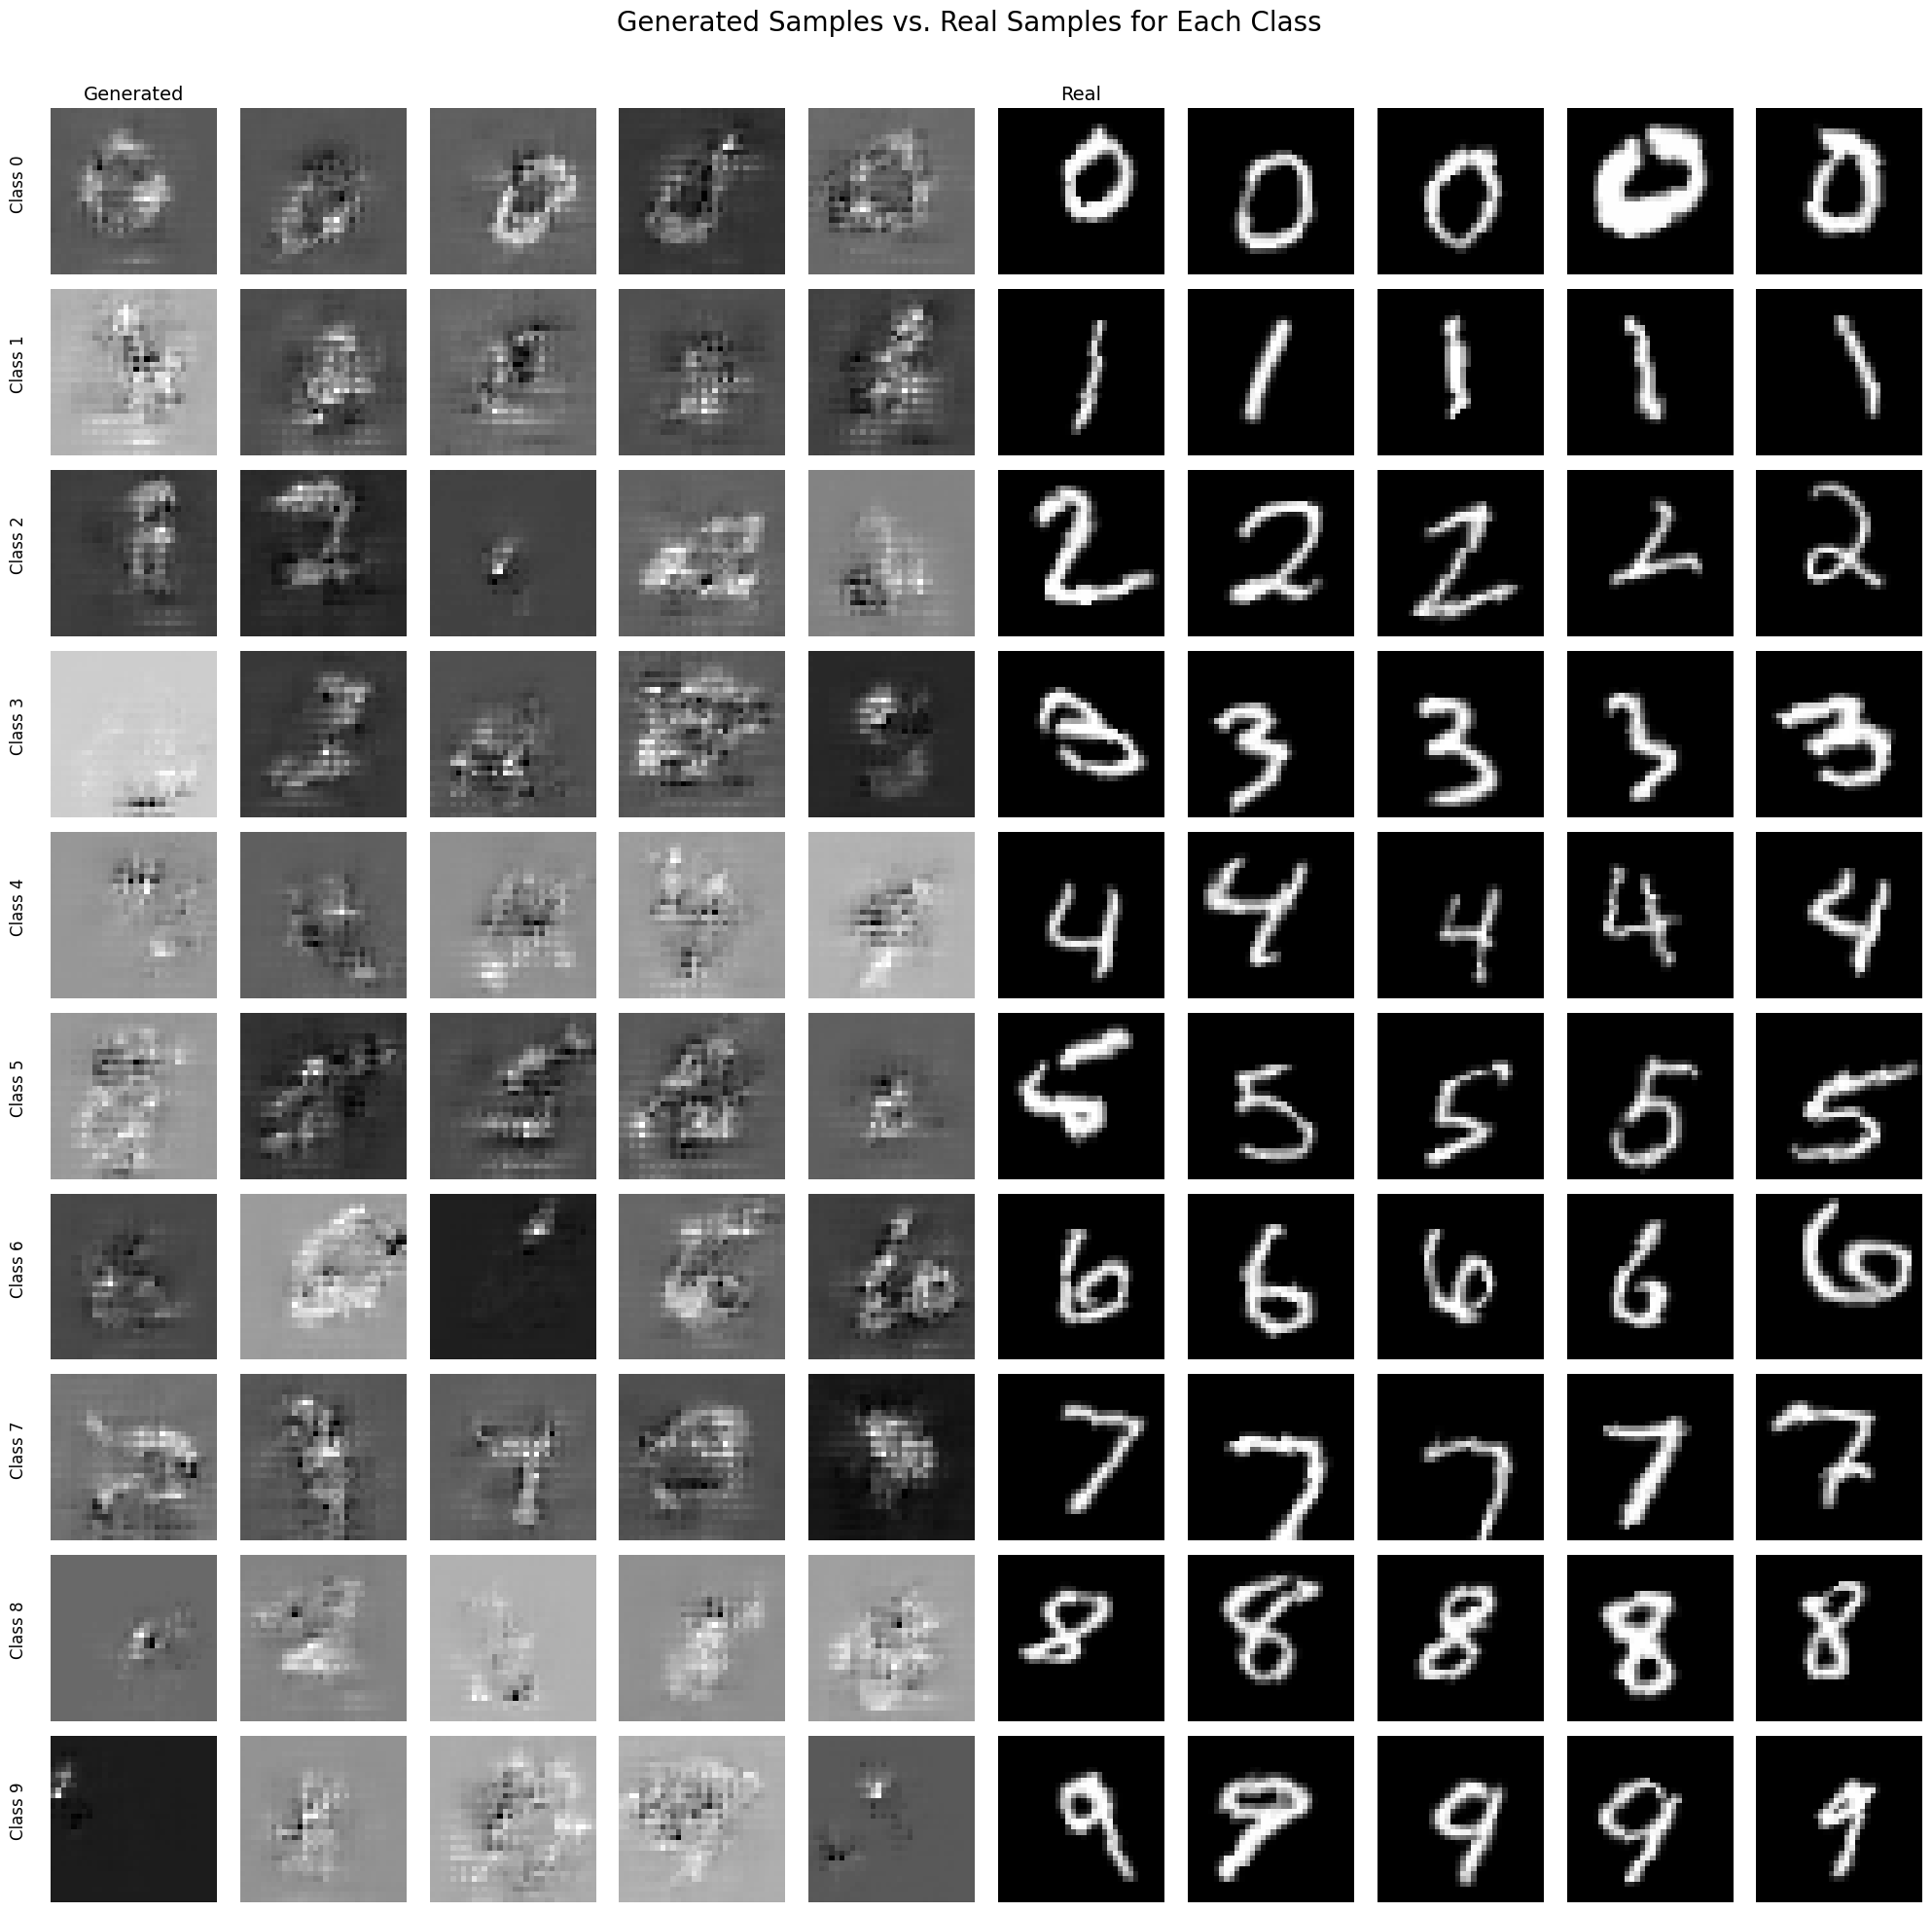

In [10]:
# --- 5. Generate and Visualize Class-wise Samples vs. Real Samples ---
# Define grid size
n_rows = 10  # One row for each class (0-9)
n_cols = 5   # Number of samples to generate/show per class

# Prepare real images by grouping them by class
real_images_by_class = {i: [] for i in range(n_rows)}
for img, label in test_dataset:
    if len(real_images_by_class[label]) < n_cols:
        real_images_by_class[label].append(img)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(n_cols * 4, n_rows * 2))
fig.suptitle('Generated Samples vs. Real Samples for Each Class', fontsize=20)

with torch.no_grad():
    # 1. Create target distributions once
    target_dists = get_target_distributions(
        trainable_means, trainable_v, cfg.training.num_classes
    )

    # 2. Sample a batch of latent vectors for all classes at once
    all_z_samples = [dist.sample(sample_shape=(n_cols,)) for dist in target_dists]
    z_batch = torch.cat(all_z_samples, dim=0) # Shape: (n_rows * n_cols, features)

    # 3. Reshape the batch for the model and generate all images in one go
    z_batch_reshaped = z_batch.view(n_rows * n_cols, 1, 32, 32)
    generated_images, _ = model.inverse(z_batch_reshaped) # Shape: (n_rows * n_cols, 1, 28, 28)

    # 4. Plot the generated and real images
    for class_idx in range(n_rows):
        # --- Plot the batch-generated images ---
        for sample_idx in range(n_cols):
            # Get the correct image from the generated batch
            image_index = class_idx * n_cols + sample_idx
            generated_image = generated_images[image_index]
            
            # Plot
            ax = axes[class_idx, sample_idx]
            ax.imshow(generated_image.squeeze().cpu().numpy(), cmap='gray')
            ax.axis('off')
            if sample_idx == 0 and class_idx == 0:
                ax.set_title("Generated", fontsize=14)

        # --- Plot real images (no change here) ---
        for sample_idx in range(n_cols):
            real_image = real_images_by_class[class_idx][sample_idx]
            ax = axes[class_idx, n_cols + sample_idx]
            ax.imshow(real_image.squeeze().numpy(), cmap='gray')
            ax.axis('off')
            if sample_idx == 0 and class_idx == 0:
                ax.set_title("Real", fontsize=14)

        # Add a label for the class on the far left of each row
        axes[class_idx, 0].text(-5, 14, f"Class {class_idx}", verticalalignment='center', horizontalalignment='right', fontsize=12, rotation=90)


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()